In [4]:
pip install pandas nltk scikit-learn beautifulsoup4 transformers torch joblib

Note: you may need to restart the kernel to use updated packages.


In [5]:
import re
import joblib
import pandas as pd
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Advanced NLP
from transformers import pipeline

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

c:\Users\Acer Swift X\miniconda3\envs\tfgpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to C:\Users\Acer Swift
[nltk_data]     X\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Acer Swift
[nltk_data]     X\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Acer Swift
[nltk_data]     X\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [6]:
# Load dataset

df = pd.read_csv("IMDB Dataset.csv")

df = df.rename(columns={
    "review": "text",
    "sentiment": "label"
})

print(df.head())

                                                text     label
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [7]:
# Preprocessing

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = BeautifulSoup(str(text), "html.parser").get_text()

    text = text.lower()

    text = re.sub(r"[^a-z\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

In [8]:
# Train test split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
# Feature extraction 

bow_vectorizer = CountVectorizer(max_features=10000)
tfidf_vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [10]:
# Model Training

models = {
    "BoW + Naive Bayes": (MultinomialNB(), X_train_bow, X_test_bow),
    "BoW + SVM": (LinearSVC(), X_train_bow, X_test_bow),
    "TF-IDF + Naive Bayes": (MultinomialNB(), X_train_tfidf, X_test_tfidf),
    "TF-IDF + SVM": (LinearSVC(), X_train_tfidf, X_test_tfidf)
}

results = []
best_model = None
best_name = None
best_accuracy = 0

In [11]:
# Evaluation

trained_models = {}

for name, (model, Xtr, Xte) in models.items():
    print("\n==============================")
    print("Training:", name)
    print("==============================")

    model.fit(Xtr, y_train)
    predictions = model.predict(Xte)

    trained_models[name] = model

    accuracy = accuracy_score(y_test, predictions)
    report = classification_report(y_test, predictions, output_dict=True)

    print("Accuracy:", accuracy)
    print(classification_report(y_test, predictions))

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    })


Training: BoW + Naive Bayes
Accuracy: 0.8513
              precision    recall  f1-score   support

    negative       0.84      0.86      0.85      5000
    positive       0.86      0.84      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


Training: BoW + SVM


c:\Users\Acer Swift X\miniconda3\envs\tfgpu\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.8479
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      5000
    positive       0.85      0.85      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


Training: TF-IDF + Naive Bayes
Accuracy: 0.8734
              precision    recall  f1-score   support

    negative       0.89      0.85      0.87      5000
    positive       0.86      0.89      0.88      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000


Training: TF-IDF + SVM
Accuracy: 0.8943
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      5000
    positive       0.89      0.90      0.90      5000

    accuracy                           0.89     10000
   macro avg       0.

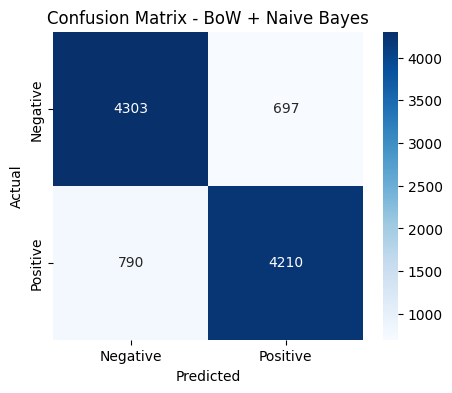

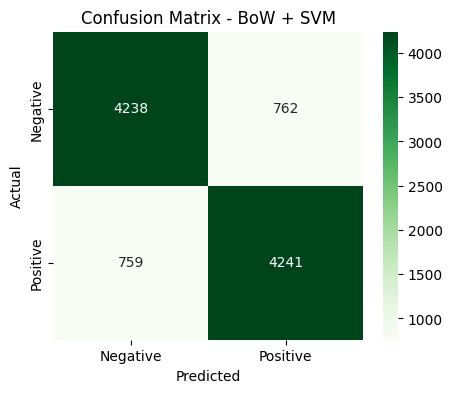

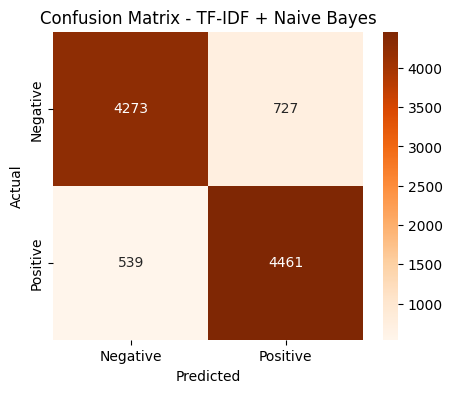

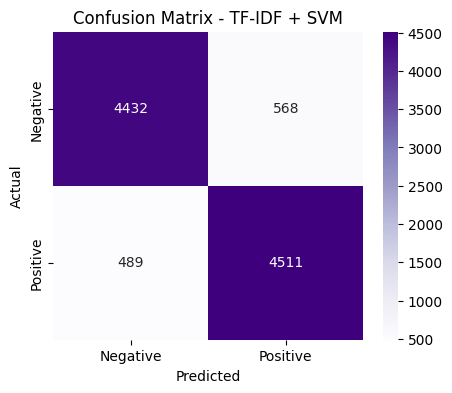

In [22]:
# Confusion matrix for each model

color_maps = {
    "BoW + Naive Bayes": "Blues",
    "BoW + SVM": "Greens",
    "TF-IDF + Naive Bayes": "Oranges",
    "TF-IDF + SVM": "Purples"
}

for name, (model, Xtr, Xte) in models.items():

    predictions = model.predict(Xte)
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=color_maps[name],
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [13]:
# Comparison table

comparison_table = pd.DataFrame(results)

print("\nModel Comparison")
print(comparison_table)


Model Comparison
                  Model  Accuracy  Precision  Recall  F1-Score
0     BoW + Naive Bayes    0.8513   0.851422  0.8513  0.851287
1             BoW + SVM    0.8479   0.847900  0.8479  0.847900
2  TF-IDF + Naive Bayes    0.8734   0.873929  0.8734  0.873355
3          TF-IDF + SVM    0.8943   0.894398  0.8943  0.894293


In [19]:
# The best model

best_row = comparison_table.loc[comparison_table["F1-Score"].idxmax()]
best_name = best_row["Model"]
best_model = trained_models[best_name]

# Select correct vectorizer
if "BoW" in best_name:
    best_vectorizer = bow_vectorizer
else:
    best_vectorizer = tfidf_vectorizer

# Save best model and vectorizer
joblib.dump(best_model, "best_model.pkl")
joblib.dump(best_vectorizer, "best_vectorizer.pkl")

print("Best Model:", best_name)
print(f"Accuracy : {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall   : {best_row['Recall']:.4f}")
print(f"F1-Score : {best_row['F1-Score']:.4f}")
print("\nSaved best_model.pkl and best_vectorizer.pkl")

Best Model: TF-IDF + SVM
Accuracy : 0.8943
Precision: 0.8944
Recall   : 0.8943
F1-Score : 0.8943

Saved best_model.pkl and best_vectorizer.pkl


In [15]:
# Advanced NLP (BERT)

bert_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

sample_review = """
The movie was emotional, exciting
and beautifully acted.
"""

bert_result = bert_model(sample_review)[0]

print("\nsample_review: The movie was emotional, exciting and beautifully acted.")
print("\nBERT Transformer Result")
print("Prediction:", bert_result["label"])
print("Confidence:", bert_result["score"])

Device set to use cpu



sample_review: The movie was emotional, exciting and beautifully acted.

BERT Transformer Result
Prediction: POSITIVE
Confidence: 0.9998865127563477
